# DLWA Analysis: GC-free vs Host-triggered GC

Comparing two zone management strategies on ZNS SSD (ConfZNS++) across different `finish_threshold` values.

- **GC-free** (`gc_mode=False`): zone finished early, no host GC, higher DLWA
- **Host GC** (`gc_mode=True`): delayed FINISH, GC mixes data by lifetime, lower DLWA but GC overhead

In [3]:
import numpy as np
import pandas as pd

In [8]:
df = pd.read_csv("../results/pages_to_write_num_3000000.csv")
df

,gc_mode,finish_threshold,total_pages_to_write,finish_call_count,latency_micros_per_op,throughput_MB_per_s,timestamp
0,False,0,0,0,19.638,50.5,2026-04-16 14:31:28
1,False,10,104311,9,18.841,52.6,2026-04-16 14:32:29
2,False,20,104252,9,18.057,54.9,2026-04-16 14:33:28
3,False,30,498982,10,18.613,53.3,2026-04-16 14:34:28
4,False,40,499006,10,19.838,50.0,2026-04-16 14:35:32
5,False,50,499155,10,19.555,50.7,2026-04-16 14:36:36
6,False,60,11659522,44,34.612,28.7,2026-04-16 14:38:25
7,False,70,11659812,44,34.688,28.6,2026-04-16 14:40:15
8,False,80,12057278,45,35.183,28.2,2026-04-16 14:42:07
9,False,90,12056987,45,35.188,28.2,2026-04-16 14:43:58


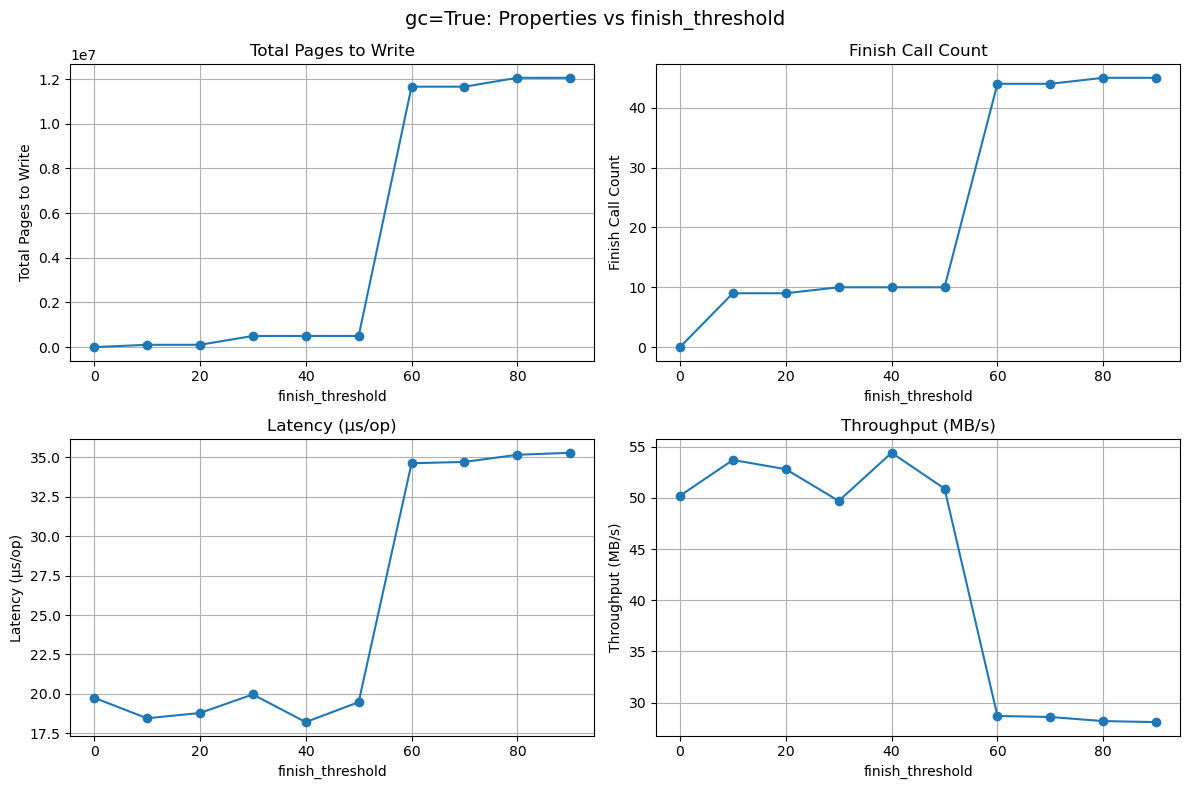

In [9]:
import matplotlib.pyplot as plt

gc_df = df[df["gc_mode"] == True].copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("gc=True: Properties vs finish_threshold", fontsize=14)

metrics = [
    ("total_pages_to_write", "Total Pages to Write"),
    ("finish_call_count",    "Finish Call Count"),
    ("latency_micros_per_op","Latency (µs/op)"),
    ("throughput_MB_per_s",  "Throughput (MB/s)"),
]

for ax, (col, label) in zip(axes.flat, metrics):
    ax.plot(gc_df["finish_threshold"], gc_df[col], marker="o")
    ax.set_xlabel("finish_threshold")
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.grid(True)

plt.tight_layout()
plt.show()
